In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

INPUTS

In [5]:
IMG_HEIGHT =224
IMG_WIDTH =224
IMG_CHANNELS =3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [6]:
transform= transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
train_dir="/content/drive/MyDrive/flower_images/train"
val_dir = "/content/drive/MyDrive/flower_images/val"

train_data=datasets.ImageFolder(root=train_dir, transform=transform)
val_data =datasets.ImageFolder(root=val_dir, transform=transform)

train_dataset=DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset= DataLoader(val_data, batch_size=16)

NETWORK ARCHITECTURE

In [7]:
class FireModule(nn.Module):
  def __init__(self, in_channel, squeeze, expand):
    super().__init__()
    self.input = in_channel
    self.squeeze = squeeze
    self.expand = expand
    self.conv1 = nn.Conv2d(in_channels= self.input, out_channels=self.squeeze,kernel_size=1, stride=1)
    self.branch1 = nn.Conv2d(in_channels= self.squeeze, out_channels= self.expand, kernel_size=1, stride=1)
    self.branch2 = nn.Conv2d(in_channels = self.squeeze, out_channels=self.expand, kernel_size=3, stride=1, padding='same')
    self.relu =nn.ReLU()

  def forward(self, x):
    x=self.conv1(x)
    x= self.relu(x)
    out1 = self.branch1(x)
    out1 = self.relu(out1)
    out2 = self.branch2(x)
    out2 = self.relu(out2)
    out = torch.cat([out1, out2], dim=1)
    return out


In [8]:
squeezenet = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 96, kernel_size=7, stride=2),
    nn.MaxPool2d(kernel_size=3, stride=2),
    FireModule(96, 16, 64),
    FireModule(128, 32, 128),
    nn.MaxPool2d(kernel_size=3, stride=2),
    FireModule(256, 48, 192),
    FireModule(384, 64, 256),
    nn.MaxPool2d(kernel_size=3, stride=2),
    FireModule(512, 64, 256),
    nn.Conv2d(512, 5, kernel_size=1, stride=1),
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten()

)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
squeezenet = squeezenet.to(device)

In [9]:
learning_rate=0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(squeezenet.parameters(), lr=learning_rate)

In [10]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss =[]
    train_acc=[]
    val_loss=[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        total_loss =0
        total_samples=0
        correct_preds=0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            batch_pred = (preds==labels).sum().item()
            correct_preds +=batch_pred
            total_samples+=labels.size(0)
            total_loss += loss.item()

        acc = correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss : {total_loss:.4f}, Accuracy : {acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)
        model.eval()
        with torch.no_grad():
            eval_loss_total =0 # Renamed for clarity
            eval_samples =0
            eval_correct_preds =0 # Renamed for clarity
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # Corrected: Get outputs for the current validation batch
                outputs = model(images)
                # Corrected: Calculate loss for the current validation batch
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                eval_correct_preds += (preds==labels).sum().item()
                eval_loss_total += loss.item() # Correctly accumulate loss
                eval_samples += labels.size(0)

            eval_acc = eval_correct_preds/eval_samples
            print(f"Val_Loss: {eval_loss_total:.4f}, Val_Accuracy : {eval_acc:.4f}")
            val_loss.append(eval_loss_total)
            val_acc.append(eval_acc)

    return train_loss, train_acc, val_loss, val_acc

TRAINING

In [11]:
EPOCHS = 50
train_loss, train_acc, val_loss, val_acc = train_model(squeezenet, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss : 271.8725, Accuracy : 0.3163
Val_Loss: 81.1469, Val_Accuracy : 0.4280
Epoch 2: Loss : 242.8976, Accuracy : 0.4300
Val_Loss: 78.6240, Val_Accuracy : 0.4280
Epoch 3: Loss : 235.8729, Accuracy : 0.4540
Val_Loss: 76.4939, Val_Accuracy : 0.4490
Epoch 4: Loss : 233.7570, Accuracy : 0.4657
Val_Loss: 74.5720, Val_Accuracy : 0.5010
Epoch 5: Loss : 225.8900, Accuracy : 0.4810
Val_Loss: 81.5146, Val_Accuracy : 0.4660
Epoch 6: Loss : 221.5186, Accuracy : 0.5053
Val_Loss: 69.6045, Val_Accuracy : 0.5510
Epoch 7: Loss : 209.1088, Accuracy : 0.5560
Val_Loss: 68.2482, Val_Accuracy : 0.5600
Epoch 8: Loss : 201.9487, Accuracy : 0.5663
Val_Loss: 65.5262, Val_Accuracy : 0.5960
Epoch 9: Loss : 190.8070, Accuracy : 0.5937
Val_Loss: 62.7238, Val_Accuracy : 0.5860
Epoch 10: Loss : 188.4019, Accuracy : 0.6017
Val_Loss: 62.5586, Val_Accuracy : 0.5920
Epoch 11: Loss : 180.0705, Accuracy : 0.6210
Val_Loss: 66.6347, Val_Accuracy : 0.6080
Epoch 12: Loss : 173.2118, Accuracy : 0.6443
Val_Loss: 60.2039,

PLOTTING

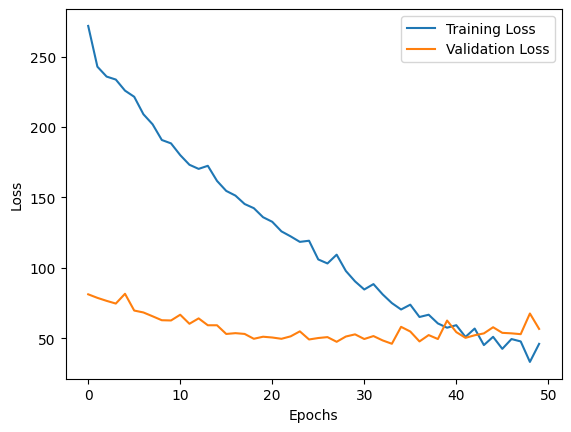

In [12]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

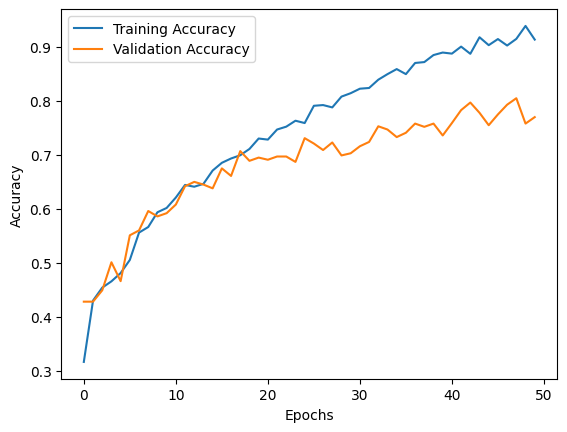

In [13]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()